In [ ]:
# ============================================
# 1. Imports
# ============================================
import re
import os
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter, defaultdict

from datasets import load_dataset, load_from_disk
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Optional: UMAP is often better than PCA/t-SNE for embeddings, but requires install
# !pip install umap-learn
# import umap


# ============================================
# 2. Configuration
# ============================================
DATASET_NAME = os.path.abspath("../dataset/text_and_sentiment")   # e.g. "csv" or local HF dataset path
DATASET_SPLIT = "train"                            # change if needed
TEXT_COL = "text"

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"

# Preprocessing
REMOVE_URLS = True
REMOVE_MENTIONS = True
NORMALIZE_WHITESPACE = True
LOWERCASE = True
REMOVE_RT = True
KEEP_HASHTAG_TEXT = True     # "#AI" -> "AI" instead of removing entire token
REMOVE_EMOJIS = False        # often useful signal; keep unless you want cleaner topic text
REMOVE_DUPLICATES = True
MIN_CHARS = 3                # filter very short texts after preprocessing

# Clustering
K_RANGE = range(2, 60)       # try 2..15
RANDOM_STATE = 42
N_INIT = 20

# Embedding / batching
BATCH_SIZE = 128
SHOW_PROGRESS_BAR = True

# Optional dimensionality reduction before clustering
USE_PCA_BEFORE_KMEANS = False
PCA_DIM = 50

# Inspection
N_REPRESENTATIVE_TWEETS = 10
TOP_TERMS_PER_CLUSTER = 15
TOP_NGRAM_RANGE = (1, 2)
TOP_TERMS_MAX_FEATURES = 5000
TOP_TERMS_MAX_DF = 0.7

# Dynamic stopword filtering for very common dataset words
ENABLE_DYNAMIC_STOPWORDS = True
COMMON_WORD_TOP_N = 120
COMMON_WORD_MIN_DOC_FRAC = 0.15

# Visualization
VIS_SAMPLE_SIZE = 3000       # subsample for t-SNE if dataset is large

In [2]:
# ============================================
# 3. Load dataset
# ============================================
# Example 1: loading a named HF dataset
# dataset = load_dataset(DATASET_NAME)

# Example 2: loading a local dataset from disk
# from datasets import load_from_disk
# dataset = load_from_disk(DATASET_NAME)

# Replace this section based on your actual setup:
dataset = load_from_disk(DATASET_NAME)

# If dataset is a DatasetDict, select split
hf_split = dataset[DATASET_SPLIT]
orig_size = hf_split.num_rows

print(hf_split)
print(hf_split.column_names)
print(f"Original size: {orig_size}")

Dataset({
    features: ['textID', 'text', 'sentiment'],
    num_rows: 24732
})
['textID', 'text', 'sentiment']
Original size: 24732


In [3]:
# ============================================
# 4. Preprocessing functions
# ============================================
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#(\w+)")
RT_PATTERN = re.compile(r"^rt\s+", re.IGNORECASE)
WHITESPACE_PATTERN = re.compile(r"\s+")

# Basic emoji range removal if needed
EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

def preprocess_tweet(text: str) -> str:
    """Basic tweet cleaning for clustering/topic discovery."""
    if text is None:
        return ""

    text = str(text)
    text = html.unescape(text)

    if LOWERCASE:
        text = text.lower()

    if REMOVE_RT:
        text = RT_PATTERN.sub("", text)

    if REMOVE_URLS:
        text = URL_PATTERN.sub(" ", text)

    if REMOVE_MENTIONS:
        text = MENTION_PATTERN.sub(" ", text)

    if KEEP_HASHTAG_TEXT:
        # Convert #AI -> AI
        text = HASHTAG_PATTERN.sub(r"\1", text)
    else:
        text = HASHTAG_PATTERN.sub(" ", text)

    if REMOVE_EMOJIS:
        text = EMOJI_PATTERN.sub(" ", text)

    if NORMALIZE_WHITESPACE:
        text = WHITESPACE_PATTERN.sub(" ", text).strip()

    return text

In [4]:
# ============================================
# 5. Convert HF dataset to DataFrame and clean
# ============================================
df = hf_split.to_pandas()

assert TEXT_COL in df.columns, f"Column '{TEXT_COL}' not found in dataset."

# df = df[[TEXT_COL]].copy()
df["raw_text"] = df[TEXT_COL].astype(str)
df["clean_text"] = df["raw_text"].apply(preprocess_tweet)

# Filter empty / too-short texts
df = df[df["clean_text"].str.len() >= MIN_CHARS].copy()

if REMOVE_DUPLICATES:
    df = df.drop_duplicates(subset=["clean_text"]).copy()

df = df.reset_index(drop=True)

num_dropped = orig_size - len(df)
print(f"Number of usable tweets: {len(df)}")
print(f"Number of tweets dropped: {num_dropped}")
df.head()

Number of usable tweets: 24655
Number of tweets dropped: 77


,textID,text,sentiment,raw_text,clean_text
0,520d2410fb,Craziier are off of msn!,neutral,Craziier are off of msn!,craziier are off of msn!
1,7956d83106,"Sadly, all I have is the Stanley Steemer 800 ...",negative,"Sadly, all I have is the Stanley Steemer 800 ...","sadly, all i have is the stanley steemer 800 n..."
2,d8104f1513,Ahhhh!!!!!! Almost off!!! Can`t wait!! But..I ...,neutral,Ahhhh!!!!!! Almost off!!! Can`t wait!! But..I ...,ahhhh!!!!!! almost off!!! can`t wait!! but..i ...
3,82849c9214,500! updates! wooow!! haha!!,positive,500! updates! wooow!! haha!!,500! updates! wooow!! haha!!
4,6f47fd4264,"Nothing like 10P to kick-off the Bank Holiday,...",neutral,"Nothing like 10P to kick-off the Bank Holiday,...","nothing like 10p to kick-off the bank holiday,..."


In [5]:
# ============================================
# 6. Load sentence embedding model
# ============================================
model = SentenceTransformer(EMBEDDING_MODEL_NAME)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
# ============================================
# 7. Generate sentence embeddings
# ============================================
texts = df["clean_text"].tolist()

embeddings = model.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=SHOW_PROGRESS_BAR,
    convert_to_numpy=True,
    normalize_embeddings=True  # often helpful for clustering cosine-like structure
)

print("Embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/193 [00:00<?, ?it/s]

Embeddings shape: (24655, 384)


In [7]:
# ============================================
# 8. Optional PCA before clustering
# ============================================
X = embeddings

if USE_PCA_BEFORE_KMEANS:
    pca = PCA(n_components=PCA_DIM, random_state=RANDOM_STATE)
    X = pca.fit_transform(embeddings)
    print("Reduced shape after PCA:", X.shape)

In [8]:
# ============================================
# 9. Choose k using silhouette + inertia
# ============================================
def evaluate_kmeans_k(X, k_range, random_state=42, n_init=20):
    """
    Returns a DataFrame with inertia and silhouette score for each k.
    """
    rows = []

    for k in k_range:
        print(f"Evaluating k={k}...")
        kmeans = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=n_init
        )
        labels = kmeans.fit_predict(X)

        inertia = kmeans.inertia_
        sil = silhouette_score(X, labels)

        rows.append({
            "k": k,
            "inertia": inertia,
            "silhouette": sil
        })

    return pd.DataFrame(rows)


results_df = evaluate_kmeans_k(
    X,
    k_range=K_RANGE,
    random_state=RANDOM_STATE,
    n_init=N_INIT
)

results_df

Evaluating k=2...
Evaluating k=3...
Evaluating k=4...
Evaluating k=5...
Evaluating k=6...
Evaluating k=7...
Evaluating k=8...
Evaluating k=9...
Evaluating k=10...
Evaluating k=11...
Evaluating k=12...
Evaluating k=13...
Evaluating k=14...
Evaluating k=15...
Evaluating k=16...
Evaluating k=17...
Evaluating k=18...
Evaluating k=19...
Evaluating k=20...
Evaluating k=21...
Evaluating k=22...
Evaluating k=23...
Evaluating k=24...
Evaluating k=25...
Evaluating k=26...
Evaluating k=27...
Evaluating k=28...
Evaluating k=29...
Evaluating k=30...
Evaluating k=31...
Evaluating k=32...
Evaluating k=33...
Evaluating k=34...
Evaluating k=35...
Evaluating k=36...
Evaluating k=37...
Evaluating k=38...
Evaluating k=39...
Evaluating k=40...
Evaluating k=41...
Evaluating k=42...
Evaluating k=43...
Evaluating k=44...
Evaluating k=45...
Evaluating k=46...
Evaluating k=47...
Evaluating k=48...
Evaluating k=49...
Evaluating k=50...
Evaluating k=51...
Evaluating k=52...
Evaluating k=53...
Evaluating k=54...
E

,k,inertia,silhouette
0,2,21136.552734,0.018544
1,3,20858.314453,0.018631
2,4,20626.664062,0.007173
3,5,20415.324219,0.009331
4,6,20237.878906,0.009603
5,7,20077.826172,0.010493
6,8,19933.710938,0.011639
7,9,19800.177734,0.013387
8,10,19688.548828,0.014595
9,11,19592.462891,0.013679


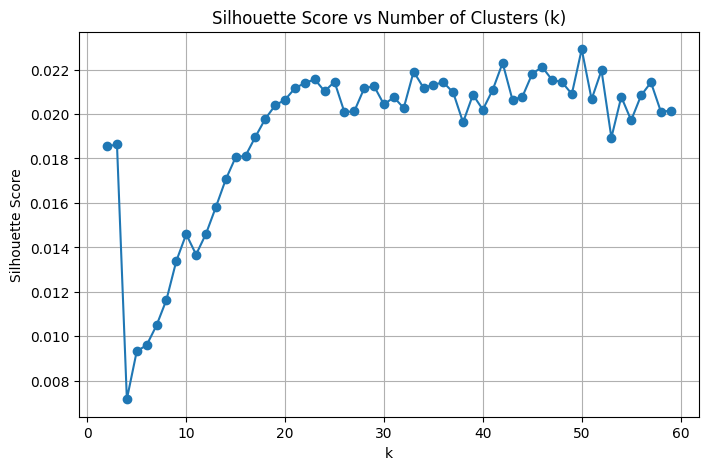

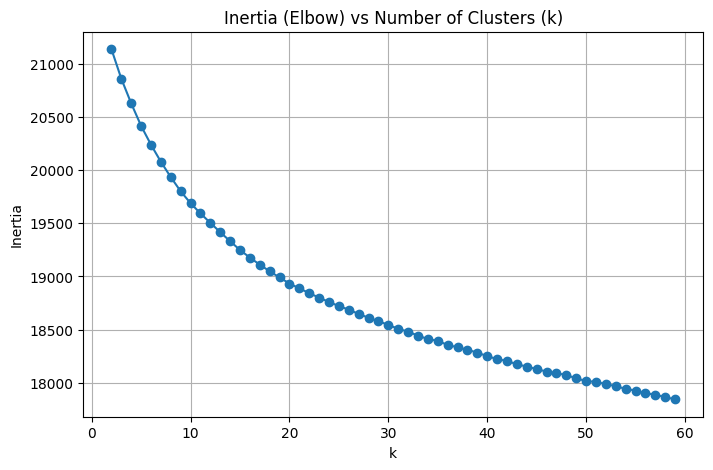

Best k by silhouette score: 50


In [9]:
# ============================================
# 10. Plot k selection metrics
# ============================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results_df["k"], results_df["silhouette"], marker="o")
ax.set_title("Silhouette Score vs Number of Clusters (k)")
ax.set_xlabel("k")
ax.set_ylabel("Silhouette Score")
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results_df["k"], results_df["inertia"], marker="o")
ax.set_title("Inertia (Elbow) vs Number of Clusters (k)")
ax.set_xlabel("k")
ax.set_ylabel("Inertia")
ax.grid(True)
plt.show()

best_k = results_df.loc[results_df["silhouette"].idxmax(), "k"]
print("Best k by silhouette score:", best_k)

In [10]:
# ============================================
# 11. Fit final KMeans
# ============================================
FINAL_K = int(best_k)  # or manually override
# FINAL_K = 53

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=N_INIT
)

df["cluster"] = kmeans.fit_predict(X)
df["cluster"] = df["cluster"].astype(int)

print(df["cluster"].value_counts().sort_index())

cluster
0     627
1     663
2     460
3     623
4     660
5     232
6     654
7     260
8     313
9     512
10    507
11    385
12    453
13    615
14    315
15    224
16    549
17     87
18    733
19    419
20    312
21    410
22    484
23    711
24    466
25    572
26    541
27    746
28    578
29    531
30    482
31    337
32    651
33    365
34    420
35    358
36    655
37    608
38    481
39    700
40    241
41    713
42    502
43    509
44    525
45    458
46    338
47    437
48    641
49    592
Name: count, dtype: int64


In [11]:
# ============================================
# 12. Representative tweets per cluster
# ============================================
def get_representative_tweets(df, X, kmeans, text_col="raw_text", n=10):
    """
    For each cluster, return tweets closest to the cluster centroid.
    """
    centers = kmeans.cluster_centers_
    cluster_to_examples = {}

    for cluster_id in sorted(df["cluster"].unique()):
        cluster_indices = np.where(df["cluster"].values == cluster_id)[0]
        cluster_vectors = X[cluster_indices]
        center = centers[cluster_id]

        # Euclidean distance to centroid
        distances = np.linalg.norm(cluster_vectors - center, axis=1)
        nearest_local_idx = np.argsort(distances)[:n]
        nearest_global_idx = cluster_indices[nearest_local_idx]

        cluster_to_examples[cluster_id] = df.iloc[nearest_global_idx][
            ["raw_text", "clean_text", "cluster"]
        ].copy()

    return cluster_to_examples


rep_examples = get_representative_tweets(
    df=df,
    X=X,
    kmeans=kmeans,
    text_col="raw_text",
    n=N_REPRESENTATIVE_TWEETS
)

for cluster_id, cluster_df in rep_examples.items():
    print("=" * 80)
    print(f"CLUSTER {cluster_id}")
    print("=" * 80)
    for i, row in cluster_df.iterrows():
        print("-", row["raw_text"])
    print()

CLUSTER 0
-  Thanks! and to you as well!
-  Awww, thank you!  & you`re welcome lol
-  thank you!
-  You`re welcome... and you`re welcome!
-  youre very welcome....you deserve it!!
-  your welcome
-  Love it! You look fabulous and it was so nice to learn something new about you
-  Your welcome hun!    They are all amazing people - make sure to say hello to them!
-   Thank you
-  THANK YOU LOVE!

CLUSTER 1
-  soooo over ppl telling me they went to the tonite show!!!  Ive had dreams of meeting him  I`m embarrassd of that a lil LOL
-  ahhh ikr! he`s the cuteset thing ever  Plus it reminds me of twilight which is good cause I looooooove it so much!!
-  That`s awesome dude, yay for surprise celebrities!  I got to meet him a few years ago, he was soooo friendly.
-  correct! I ADORE him. I just plucked him up and put him under my arm cuz he was cryin.  All better now! Hahaha
- Watch Jay Leno tonite!!!  It`s his last day as the Tonight Show Host
- shack idol today(: can`t wait. it`s gonna be fu

In [16]:
# ============================================
# 13. Top terms per cluster
# ============================================
def build_dynamic_stopwords(text_series, top_n=120, min_doc_frac=0.15):
    """
    Build extra stopwords from words that appear in many documents.
    This helps remove dataset-specific high-frequency words.
    """
    token_pattern = re.compile(r"[a-zA-Z]{2,}")
    doc_freq = Counter()
    total_docs = len(text_series)

    for text in text_series:
        tokens = set(token_pattern.findall(str(text).lower()))
        doc_freq.update(tokens)

    min_doc_count = max(1, int(np.ceil(total_docs * min_doc_frac)))
    common_tokens = [
        token for token, count in doc_freq.items()
        if count >= min_doc_count
    ]

    # Keep the most common terms by document frequency
    common_tokens = sorted(common_tokens, key=lambda t: (-doc_freq[t], t))
    return set(common_tokens[:top_n])


def extract_top_terms_per_cluster(
    df,
    text_col="clean_text",
    cluster_col="cluster",
    top_n=15,
    ngram_range=(1, 2),
    max_features=5000,
    max_df=1.0,
    dynamic_stopwords=None
):
    """
    Computes top terms for each cluster using average term frequency.
    This is a simple, interpretable topic-labeling helper.
    """
    extra_stopwords = set(dynamic_stopwords or [])
    stop_words = list(ENGLISH_STOP_WORDS.union(extra_stopwords))

    vectorizer = CountVectorizer(
        stop_words=stop_words,
        ngram_range=ngram_range,
        max_features=max_features,
        max_df=max_df
    )

    X_bow = vectorizer.fit_transform(df[text_col])
    vocab = np.array(vectorizer.get_feature_names_out())

    cluster_top_terms = {}

    for cluster_id in sorted(df[cluster_col].unique()):
        cluster_mask = (df[cluster_col].values == cluster_id)
        cluster_matrix = X_bow[cluster_mask]

        # Mean frequency within cluster
        mean_counts = np.asarray(cluster_matrix.mean(axis=0)).ravel()
        top_idx = np.argsort(mean_counts)[::-1][:top_n]
        cluster_top_terms[cluster_id] = vocab[top_idx].tolist()

    return cluster_top_terms


dynamic_stopwords = set()
if ENABLE_DYNAMIC_STOPWORDS:
    dynamic_stopwords = build_dynamic_stopwords(
        df["clean_text"],
        top_n=COMMON_WORD_TOP_N,
        min_doc_frac=COMMON_WORD_MIN_DOC_FRAC
    )
    print(f"Dynamic stopwords added: {len(dynamic_stopwords)}")
    print("Sample:", sorted(dynamic_stopwords)[:30])

top_terms = extract_top_terms_per_cluster(
    df,
    text_col="clean_text",
    cluster_col="cluster",
    top_n=TOP_TERMS_PER_CLUSTER,
    ngram_range=TOP_NGRAM_RANGE,
    max_features=TOP_TERMS_MAX_FEATURES,
    max_df=TOP_TERMS_MAX_DF,
    dynamic_stopwords=dynamic_stopwords
)

for cluster_id, terms in top_terms.items():
    print(f"Cluster {cluster_id}: {terms}")

Dynamic stopwords added: 6
Sample: ['and', 'it', 'my', 'the', 'to', 'you']
Cluster 0: ['thanks', 'thank', 'love', 'welcome', 'good', 'great', 'nice', 'glad', 'happy', 'like', 'really', 'just', 'day', 'new', 'awesome']
Cluster 1: ['love', 'just', 'like', 'lol', 'got', 'know', 'think', 'good', 'really', 'guy', 'going', 'haha', 'today', 'great', 'hope']
Cluster 2: ['hurts', 'just', 'got', 'hurt', 'today', 'pain', 'like', 'really', 'sore', 'bad', 'feel', 'im', 'legs', 'don', 'hope']
Cluster 3: ['day', 'happy', 'mother', 'mother day', 'mothers', 'happy mother', 'mothers day', 'happy mothers', 'mom', 'love', 'moms', 'mommy', 'day mothers', 'good', 'mum']
Cluster 4: ['going', 'fun', 'just', 'll', 'got', 'tomorrow', 'hope', 'today', 'tonight', 'home', 'good', 'im', 'wish', 'come', 'time']
Cluster 5: ['follow', 'followers', 'following', 'new', 'people', 'follower', 'dm', 'new followers', 'just', 'thanks', 'lol', 'like', 'don', 'im', 'love']
Cluster 6: ['know', 'oh', 'just', 'yeah', 'think', 'ri

In [17]:
# ============================================
# 14. Cluster summary table
# ============================================
summary_rows = []

for cluster_id in sorted(df["cluster"].unique()):
    cluster_size = (df["cluster"] == cluster_id).sum()
    terms = ", ".join(top_terms[cluster_id][:10])

    summary_rows.append({
        "cluster": cluster_id,
        "size": cluster_size,
        "top_terms": terms
    })

# summary_df = pd.DataFrame(summary_rows).sort_values("size", ascending=False)
summary_df = pd.DataFrame(summary_rows)
summary_df

,cluster,size,top_terms
0,0,627,"thanks, thank, love, welcome, good, great, nic..."
1,1,663,"love, just, like, lol, got, know, think, good,..."
2,2,460,"hurts, just, got, hurt, today, pain, like, rea..."
3,3,623,"day, happy, mother, mother day, mothers, happy..."
4,4,660,"going, fun, just, ll, got, tomorrow, hope, tod..."
5,5,232,"follow, followers, following, new, people, fol..."
6,6,654,"know, oh, just, yeah, think, right, yes, good,..."
7,7,260,"drink, drinking, beer, wine, drunk, night, jus..."
8,8,313,"exam, exams, today, study, test, just, good, t..."
9,9,512,"eat, just, food, eating, lunch, hungry, dinner..."


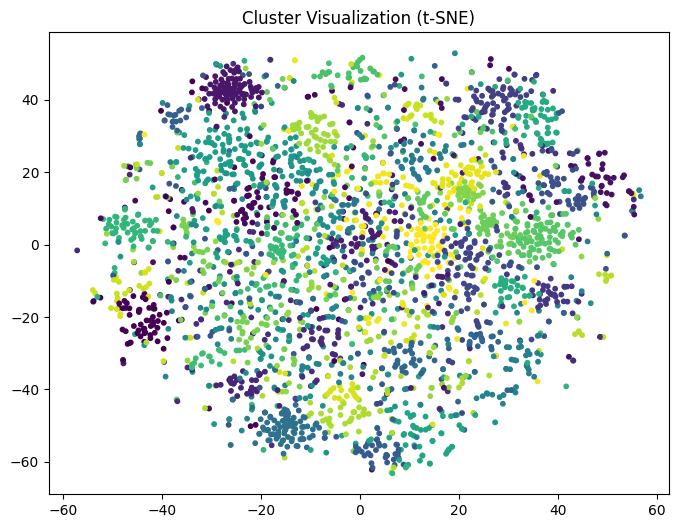

In [14]:
# ============================================
# 15. Optional 2D visualization of clusters
# ============================================
# For large datasets, t-SNE can be slow. Subsample if needed.
plot_df = df.copy()
plot_X = X.copy()

if len(plot_df) > VIS_SAMPLE_SIZE:
    sampled_idx = np.random.RandomState(RANDOM_STATE).choice(
        len(plot_df), size=VIS_SAMPLE_SIZE, replace=False
    )
    plot_df = plot_df.iloc[sampled_idx].reset_index(drop=True)
    plot_X = plot_X[sampled_idx]

# # Option A: PCA to 2D
# pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
# X_2d = pca_2d.fit_transform(plot_X)

# plt.figure(figsize=(8, 6))
# scatter = plt.scatter(
#     X_2d[:, 0],
#     X_2d[:, 1],
#     c=plot_df["cluster"],
#     s=10
# )
# plt.title("Cluster Visualization (PCA 2D)")
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.show()

# Option B: t-SNE (slower but often visually nicer)
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca", perplexity=30)
X_tsne = tsne.fit_transform(plot_X)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=plot_df["cluster"], s=10)
plt.title("Cluster Visualization (t-SNE)")
plt.show()

In [18]:
# ============================================
# 16. Optional: Save outputs
# ============================================
df.to_csv("twitter_kmeans_clustered.csv", index=False)
summary_df.to_csv("twitter_kmeans_cluster_summary.csv", index=False)

print("Saved:")
print("- twitter_kmeans_clustered.csv")
print("- twitter_cluster_summary.csv")

Saved:
- twitter_kmeans_clustered.csv
- twitter_cluster_summary.csv
